In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [74]:
data = pd.read_excel("/Users/macbook/Documents/data/FL199.xlsx").values
y = data[:, 0]
X = data[:, 1:]
wavelengths = np.linspace(942, 1701, X.shape[1])

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=30)

In [76]:
pls = PLSRegression(n_components=20)
pls.fit(X_train, y_train)
# Predicting the test set results预测测试集结果
y_pred_diff = pls.predict(X_test)


/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/cross_decomposition/_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


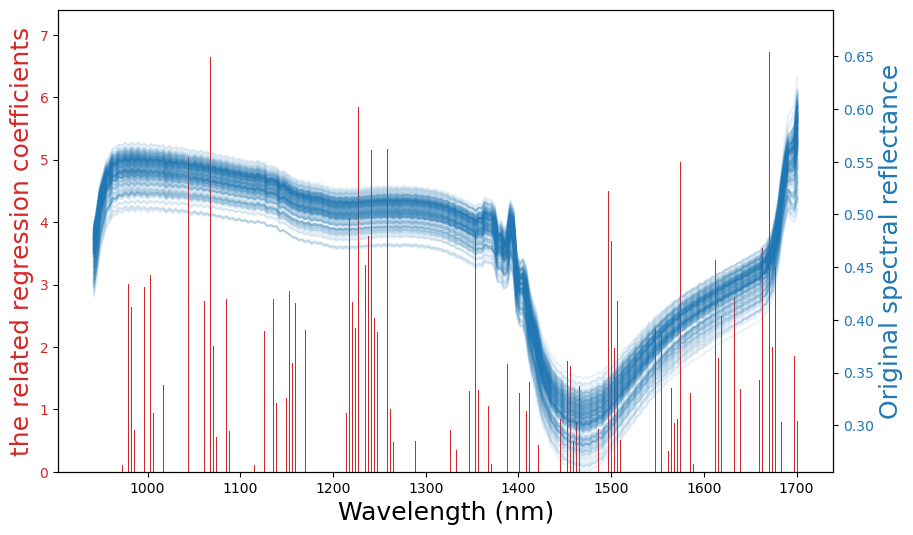

In [77]:
new_pls_coef = np.copy(pls.coef_).reshape(-1)

# Get scores

scores = new_pls_coef

# plot VIP scores and spectra on the same figure在同一个图上绘制分数和光谱
fig, ax1 = plt.subplots(figsize=(10, 6))

# plot VIP scores画VIP分数
color = 'tab:red'
ax1.bar(wavelengths, scores, color=color, alpha=1)
ax1.set_xlabel('Wavelength (nm)',fontsize=18)
ax1.set_ylabel('the related regression coefficients', color=color,fontsize=18)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([0, max(scores)*1.1])

# plot spectra画光谱
ax2 = ax1.twinx()
color = 'tab:blue'
for i in range(X.shape[0]):
    ax2.plot(wavelengths, X[i, :], alpha=0.1, color=color)

ax2.set_ylabel('Original spectral reflectance', color=color,fontsize=18)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([min(X.flatten()), max(X.flatten())*1.1])

# plt.title('scores and Spectra')
plt.show()

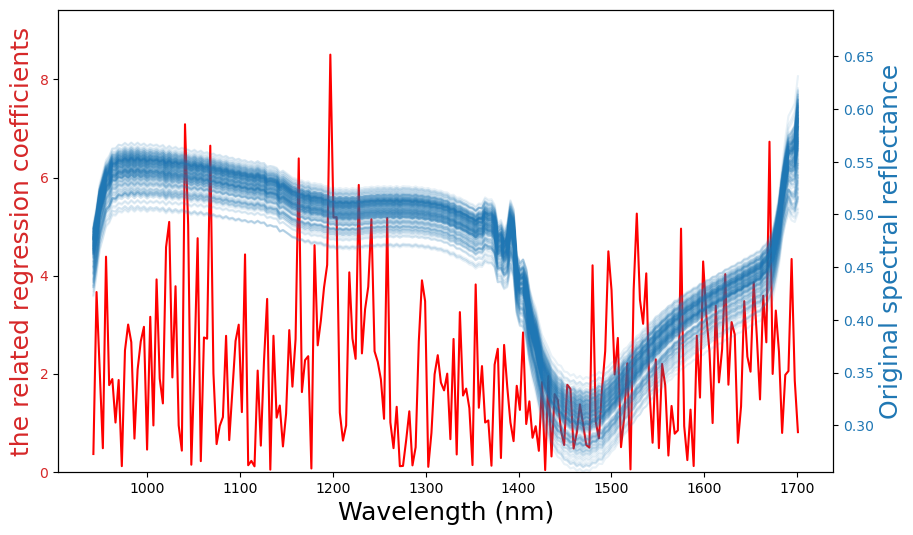

In [84]:
new_pls_coef = np.copy(pls.coef_).reshape(-1)

# Get scores

scores = new_pls_coef

# plot VIP scores and spectra on the same figure在同一个图上绘制分数和光谱
fig, ax1 = plt.subplots(figsize=(10, 6))

# plot VIP scores画VIP分数
color = 'tab:red'
# ax1.bar(wavelengths, scores, color=color, alpha=1)
plt.plot(wavelengths, np.abs(pls.coef_[:,0]),color='r')
ax1.set_xlabel('Wavelength (nm)',fontsize=18)
ax1.set_ylabel('the related regression coefficients', color=color,fontsize=18)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([0, max(scores)*1.4])

# plot spectra画光谱
ax2 = ax1.twinx()
color = 'tab:blue'
for i in range(X.shape[0]):
    ax2.plot(wavelengths, X[i, :], alpha=0.1, color=color)

ax2.set_ylabel('Original spectral reflectance', color=color,fontsize=18)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([min(X.flatten()), max(X.flatten())*1.1])

# plt.title('scores and Spectra')
plt.show()

In [79]:
scores

array([-0.36108747,  3.66473318, -2.09366392, -0.47903934, -4.38595372,
       -1.76617146, -1.88975013, -1.00310539,  1.8706055 ,  0.11366215,
       -2.47442347,  3.00145552,  2.64239472,  0.67554424, -2.0849717 ,
        2.65858173,  2.9553541 , -0.45126043,  3.15950558,  0.9438683 ,
        3.92237304,  1.89968045,  1.39319213, -4.57909614, -5.09497648,
       -1.92319759, -3.78287279, -0.94505067, -0.43035906, -7.08660582,
        5.03141513, -0.14293572, -2.20779841,  4.76255698, -0.2155055 ,
        2.73773677, -2.71389514,  6.6494862 ,  2.0087311 ,  0.56341688,
        0.93709377, -1.11439306,  2.77181017,  0.64495665, -1.64596683,
       -2.66611802, -2.99898996,  1.21575363, -4.43197481, -0.13211517,
       -0.22112444,  0.11007128, -2.06286522, -0.53197741,  2.25236034,
       -3.52443653, -0.04235795,  2.77296319,  1.10346548,  1.3500569 ,
        0.51547935,  1.18599954,  2.88874765,  1.73529685,  2.70613593,
        6.39023379,  1.62448935,  2.27658352, -2.35641286, -0.06

In [80]:
wavelengths.shape

(224,)